# Time Channel Data Smoothing

- Load and normalize the NE ATEM data.
- Bin each flight line at 50 m spacing.
- Map binned data by time channel in x-y space.
- Smooth the binned data with KDTree neighbors.
- Compare original and smoothed data with a normalized L2 norm.
- Extract locations where the normalized L2 norm is greater than 0.3.


In [60]:
import json

import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from ipywidgets import widgets
from ipywidgets import VBox, HBox, interactive_output
from scipy.spatial import cKDTree as KDTree

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True


## Load Configuration

Select the time channels used in the previous inversion workflow.


In [61]:
istart_channel: int = 3
iend_channel: int = 25

conf = json.load(open("../../atem/data/atem.json"))
times = np.asarray(conf["channels"])[istart_channel:iend_channel] * 1e-6
n_turns = conf["n_turns"]

dheader = [f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]
time_labels = [f"{name} / {time:.2e} s" for name, time in zip(dheader, times)]


## Load And Normalize Data

Read the NE survey data and apply the same normalization used in notebook 06.


In [62]:
area: str = "NE"
path: str = f"../../atem/data/11-024_Alberta_{area}.csv"
picker = [
    "Line",
    "bheight",
    "TranPeak",
    "x_wgs84",
    "y_wgs84",
    "flight",
    "pwrline",
    "dtm",
] + dheader

raws = pd.read_csv(path)[picker]
xy_raw = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9) / (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[dheader] = raws[dheader] * normalizer
line_no = list(raws["Line"].unique())


## Check Missing Coordinates

Identify flight lines with missing y coordinates before binning.


<StringArray>
['L10151', 'L10460', 'L10660', 'L10700']
Length: 4, dtype: str

[65, 1, 280, 1045]

/var/folders/2c/w5d04hwn6k56y8m_fmjdt1v40000gn/T/ipykernel_19936/797230168.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


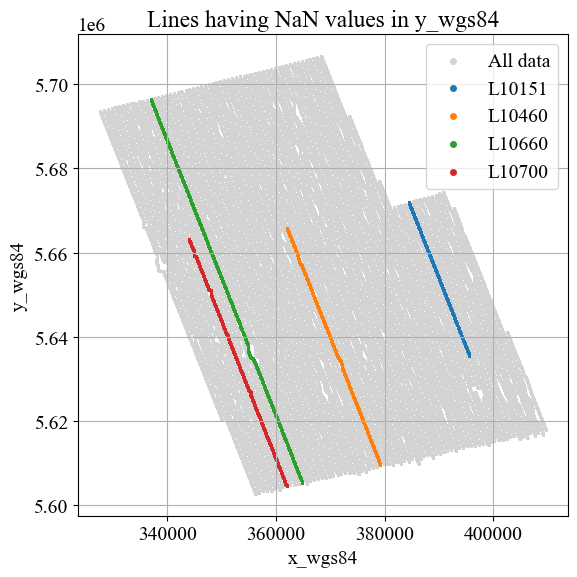

In [63]:
nan_list = raws[raws["y_wgs84"].isna()]["Line"].unique()
print(nan_list)

counts = []
for line_n in nan_list:
    count = raws[raws["Line"] == line_n]["y_wgs84"].isna().sum()
    counts.append(count)
print(counts)

plt.figure(figsize=(6, 6))
plt.scatter(xy_raw[:, 0], xy_raw[:, 1], s=1, c="lightgray", label="All data")
for i, line_n in enumerate(nan_list):
    test_x = raws[raws["Line"] == line_n]["x_wgs84"]
    test_y = raws[raws["Line"] == line_n]["y_wgs84"]
    plt.scatter(test_x, test_y, s=1, c=f"C{i}", label=line_n)
plt.xlabel("x_wgs84")
plt.ylabel("y_wgs84")
plt.title("Lines having NaN values in y_wgs84")
plt.legend(markerscale=4)
plt.tight_layout()


## Clean And Bin Data

Remove missing y coordinates and bin each line at 50 m spacing.


In [64]:
raws.dropna(subset=["y_wgs84"], inplace=True)
raws.fillna(1e-20, inplace=True)

dx = 50.0
values = []
values_std = []
soundings = []
istart = 0
iend = len(line_no)

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws["Line"] == line].copy()

    xy_line = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy_line - xy_line[0, :]) ** 2).sum(axis=1))
    max_distance = distance.max()

    if max_distance % dx == 0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    bins = np.arange(n_sounding) * dx
    df_line.insert(0, "distance", distance)
    df_line["bin"] = pd.cut(df_line["distance"], bins=bins)

    binned = (
        df_line.groupby("bin", observed=False)
        [["distance"] + picker[1:]]
        .mean()
    )
    binned.insert(0, "Line", line)

    binned_std = (
        df_line.groupby("bin", observed=False)
        [["bheight"] + dheader]
        .std()
    )

    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(
    data=np.vstack(values),
    columns=["Line", "distance"] + picker[1:],
)
df_data_std_binned = pd.DataFrame(
    data=np.vstack(values_std),
    columns=["bheight"] + dheader,
)

valid_xy = np.isfinite(df_data_binned[["x_wgs84", "y_wgs84"]].values.astype(float)).all(axis=1)
if not valid_xy.all():
    print(f"Dropping {(~valid_xy).sum():,} empty binned rows before mapping.")
    df_data_binned = df_data_binned.loc[valid_xy].reset_index(drop=True)
    df_data_std_binned = df_data_std_binned.loc[valid_xy].reset_index(drop=True)

xy_binned = df_data_binned[["x_wgs84", "y_wgs84"]].values.astype(float)
data_binned = df_data_binned[dheader].values.astype(float)
data_to_plot = -data_binned
plot_skip = 5
plot_indices = np.arange(0, xy_binned.shape[0], plot_skip)

print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Time channels: {data_binned.shape[1]}")
print(f"Plotting every {plot_skip} sounding(s): {len(plot_indices):,} points")


Binned soundings: 134,101

Time channels: 22

Plotting every 5 sounding(s): 26,821 points

## Original Time-Channel Map

Display the binned data in x-y space for a selected time channel.


In [74]:
def get_channel_limits(values, i_time, lower=2, upper=98):
    channel_values = values[:, i_time]
    finite = np.isfinite(channel_values)
    if not finite.any():
        return None, None
    return np.nanpercentile(channel_values[finite], [lower, upper])


map_line_options = [str(line) for line in pd.unique(df_data_binned["Line"])]


def plot_original_time_channel(i_time, line_name):
    vmin, vmax = get_channel_limits(data_to_plot, i_time)
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    background_indices = plot_indices[~line_mask[plot_indices]]

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    out = ax.scatter(
        xy_binned[background_indices, 0],
        xy_binned[background_indices, 1],
        c=data_to_plot[background_indices, i_time],
        s=1,
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        edgecolors="none",
    )
    ax.scatter(
        xy_binned[line_mask, 0],
        xy_binned[line_mask, 1],
        c=data_to_plot[line_mask, i_time],
        s=12,
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.15,
    )
    colorbar_mappable = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap="turbo")
    colorbar_mappable.set_array([])
    cb = plt.colorbar(colorbar_mappable, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08)
    cb.set_label("-dB/dt")
    ax.set_xlabel("x_wgs84")
    ax.set_ylabel("y_wgs84")
    ax.set_aspect(1)
    ax.set_title(f"Original data: {time_labels[i_time]}, Line {line_name}")
    plt.tight_layout()
    plt.show()

original_time_slider = widgets.SelectionSlider(
    options=[(label, i) for i, label in enumerate(time_labels)],
    value=0,
    description="Time:",
    continuous_update=False,
)
original_line_slider = widgets.SelectionSlider(
    options=map_line_options,
    value=map_line_options[0],
    description="Line:",
    continuous_update=False,
)
original_output = interactive_output(
    plot_original_time_channel,
    {"i_time": original_time_slider, "line_name": original_line_slider},
)

VBox([original_time_slider, original_line_slider, original_output])


## KDTree Smoothing

Smooth each sounding with nearby soundings using a weak distance-weighted average.
- idw_power : $1/(distance + epsilon)^{power}$


In [86]:
# Smaller k and larger IDW power make the smoothing weaker.
k_nearest_points = 50
idw_epsilon = 20.0
idw_power_early = 1.5
idw_power_late = 2.5
idw_power_by_time = np.linspace(idw_power_early, idw_power_late, data_binned.shape[1])
# idw_power_by_time = np.full(data_binned.shape[1], 0.0)

n_neighbors = min(k_nearest_points, xy_binned.shape[0])
smoothing_chunk_size = 50_000
tree = KDTree(xy_binned)
smoothed_data = np.empty_like(data_binned)

for start in range(0, xy_binned.shape[0], smoothing_chunk_size):
    end = min(start + smoothing_chunk_size, xy_binned.shape[0])
    distances, neighbor_indices = tree.query(xy_binned[start:end], k=n_neighbors)

    if n_neighbors == 1:
        distances = distances[:, None]
        neighbor_indices = neighbor_indices[:, None]

    weights_by_time = 1.0 / ((distances[:, :, None] + idw_epsilon) ** idw_power_by_time[None, None, :])
    smoothed_data[start:end] = (
        np.sum(weights_by_time * data_binned[neighbor_indices, :], axis=1)
        / np.sum(weights_by_time, axis=1)
    )

smoothed_data_to_plot = -smoothed_data

print(f"KDTree neighbors: {n_neighbors}")
print(f"IDW epsilon: {idw_epsilon}")
print(f"IDW power range: {idw_power_by_time[0]:.2f} to {idw_power_by_time[-1]:.2f}")
print(f"Smoothing chunk size: {smoothing_chunk_size:,}")

pd.DataFrame(
    {
        "channel": dheader,
        "time_s": times,
        "idw_power": idw_power_by_time,
    }
)


KDTree neighbors: 50

IDW epsilon: 20.0

IDW power range: 1.50 to 2.50

Smoothing chunk size: 50,000

,channel,time_s,idw_power
0,zoff30[3],0.000188,1.500000
1,zoff30[4],0.000230,1.547619
2,zoff30[5],0.000286,1.595238
3,zoff30[6],0.000341,1.642857
4,zoff30[7],0.000397,1.690476
5,zoff30[8],0.000452,1.738095
6,zoff30[9],0.000508,1.785714
7,zoff30[10],0.000563,1.833333
8,zoff30[11],0.000619,1.880952
9,zoff30[12],0.000688,1.928571


## Original And Smoothed Slices

Compare original and smoothed maps by time channel.


In [87]:
def plot_time_channel_comparison(i_time, line_name):
    values_pair = np.r_[data_to_plot[:, i_time], smoothed_data_to_plot[:, i_time]]
    finite = np.isfinite(values_pair)
    vmin, vmax = np.nanpercentile(values_pair[finite], [2, 98])
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    background_indices = plot_indices[~line_mask[plot_indices]]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    titles = ["Original", "KDTree smoothed"]
    arrays = [data_to_plot[:, i_time], smoothed_data_to_plot[:, i_time]]

    for ax, title, values_i in zip(axs, titles, arrays):
        out = ax.scatter(
            xy_binned[background_indices, 0],
            xy_binned[background_indices, 1],
            c=values_i[background_indices],
            s=1,
            cmap="turbo",
            vmin=vmin,
            vmax=vmax,
            edgecolors="none",
        )
        ax.scatter(
            xy_binned[line_mask, 0],
            xy_binned[line_mask, 1],
            c=values_i[line_mask],
            s=12,
            cmap="turbo",
            vmin=vmin,
            vmax=vmax,
            linewidths=0.15,
        )
        ax.set_xlabel("x_wgs84")
        ax.set_ylabel("y_wgs84")
        ax.set_aspect(1)
        ax.set_title(f"{title}: {time_labels[i_time]}, Line {line_name}")

    colorbar_mappable = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap="turbo")
    colorbar_mappable.set_array([])
    cb = fig.colorbar(colorbar_mappable, ax=axs, orientation="horizontal", fraction=0.05, pad=0.08)
    cb.set_label("dB/dt")
    plt.show()

comparison_time_slider = widgets.SelectionSlider(
    options=[(label, i) for i, label in enumerate(time_labels)],
    value=0,
    description="Time:",
    continuous_update=False,
)
comparison_line_slider = widgets.SelectionSlider(
    options=map_line_options,
    value=map_line_options[0],
    description="Line:",
    continuous_update=False,
)
comparison_output = interactive_output(
    plot_time_channel_comparison,
    {"i_time": comparison_time_slider, "line_name": comparison_line_slider},
)

VBox([comparison_time_slider, comparison_line_slider, comparison_output])


## Line Comparison

Compare original and smoothed data along a selected flight line.


In [88]:
line_options = [str(line) for line in pd.unique(df_data_binned["Line"])]


def plot_line_original_smoothed(line_name, mode):
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    if not line_mask.any():
        raise ValueError(f"No data found for line {line_name}")

    distances = df_data_binned.loc[line_mask, "distance"].values.astype(float)
    sort_idx = np.argsort(distances)
    distances = distances[sort_idx]

    original_line = -data_binned[line_mask, :][sort_idx, :]
    smoothed_line = -smoothed_data[line_mask, :][sort_idx, :]
    difference_line = original_line - smoothed_line

    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    if mode == "all channels":
        for i_time in range(data_binned.shape[1]):
            ax.semilogy(distances, np.abs(original_line[:, i_time]), "k-", linewidth=0.7, alpha=0.35)
            ax.semilogy(distances, np.abs(smoothed_line[:, i_time]), "C0--", linewidth=0.7, alpha=0.55)
        ax.set_ylabel("|-dB/dt|")
        ax.set_title(f"Original vs smoothed data: Line {line_name}")
        ax.legend(["Original", "Smoothed"], loc="best")
    else:
        i_time = int(mode)
        ax.plot(distances, original_line[:, i_time], "k-", linewidth=1.2, label="Original")
        ax.plot(distances, smoothed_line[:, i_time], "C0--", linewidth=1.2, label="Smoothed")
        ax.plot(distances, difference_line[:, i_time], "C3-", linewidth=0.8, alpha=0.8, label="Original - smoothed")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_ylabel("-dB/dt")
        ax.set_title(f"{time_labels[i_time]}: Line {line_name}")
        ax.legend(loc="best")

    ax.set_xlabel("Distance along line (m)")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

line_comparison_dropdown = widgets.Dropdown(
    options=line_options,
    value=line_options[0],
    description="Line:",
)
line_mode_dropdown = widgets.Dropdown(
    options=[("All channels", "all channels")] + [(label, i) for i, label in enumerate(time_labels)],
    value="all channels",
    description="Mode:",
)
line_comparison_output = interactive_output(
    plot_line_original_smoothed,
    {"line_name": line_comparison_dropdown, "mode": line_mode_dropdown},
)

VBox([line_comparison_dropdown, line_mode_dropdown, line_comparison_output])


## Normalized L2 Difference

Compute the L2 difference between original and smoothed data at each sounding.


In [69]:
l2_difference = np.linalg.norm(data_binned - smoothed_data, axis=1)
l2_smoothed = np.linalg.norm(smoothed_data, axis=1)
normalized_l2_difference = np.divide(
    l2_difference,
    l2_smoothed,
    out=np.full_like(l2_difference, np.nan, dtype=float),
    where=l2_smoothed > 0,
)

l2_threshold = 0.3
high_l2_mask = normalized_l2_difference > l2_threshold
high_l2_locations = df_data_binned.loc[
    high_l2_mask,
    ["Line", "distance", "x_wgs84", "y_wgs84", "bheight", "pwrline", "dtm"],
].copy()
high_l2_locations["normalized_l2_difference"] = normalized_l2_difference[high_l2_mask]

print(f"Locations above {l2_threshold}: {high_l2_mask.sum():,} / {len(high_l2_mask):,}")
high_l2_locations.head()


Locations above 0.3: 504 / 134,101

,Line,distance,x_wgs84,y_wgs84,bheight,pwrline,dtm,normalized_l2_difference
2839,L10060,59575.06843,408157.171957,5617373.814311,57.280923,2.0,783.930426,0.333881
2840,L10060,59625.178157,408172.745608,5617326.176296,64.420687,2.0,783.715601,0.408762
2841,L10060,59674.694069,408187.969656,5617279.052363,71.240334,1.588235,783.77387,0.464212
2842,L10060,59725.073744,408203.392692,5617231.086047,78.069948,1.0,783.193744,0.514892
2843,L10060,59776.024546,408218.340661,5617182.377266,83.826377,1.0,783.428505,0.684123


Finite values: 134,101 / 134,101

Mean: 0.04912

Std: 0.04744

Max: 1.275

Fraction above 0.3: 0.38%

,normalized_l2_difference
p0,0.000195
p25,0.017752
p50,0.037136
p75,0.066193
p90,0.102002
p95,0.130034
p99,0.215989
p100,1.274929


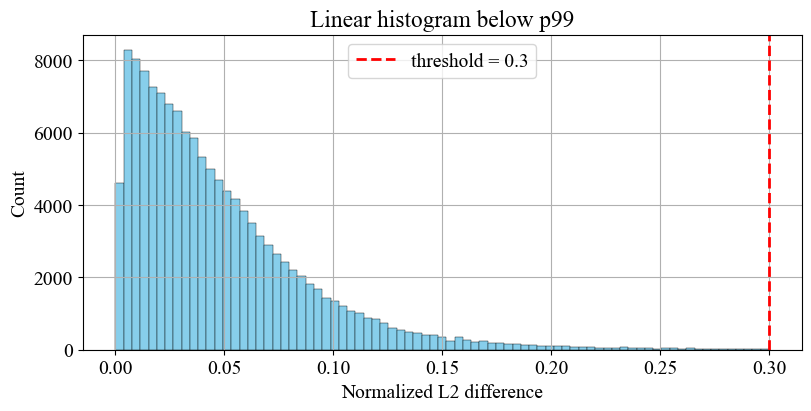

In [70]:
valid_l2 = normalized_l2_difference[np.isfinite(normalized_l2_difference)]
quantile_levels = [0, 25, 50, 75, 90, 95, 99, 100]
l2_quantiles = pd.Series(
    np.nanpercentile(valid_l2, quantile_levels),
    index=[f"p{q}" for q in quantile_levels],
    name="normalized_l2_difference",
)

print(f"Finite values: {valid_l2.size:,} / {normalized_l2_difference.size:,}")
print(f"Mean: {np.nanmean(valid_l2):.4g}")
print(f"Std: {np.nanstd(valid_l2):.4g}")
print(f"Max: {np.nanmax(valid_l2):.4g}")
print(f"Fraction above {l2_threshold}: {np.nanmean(normalized_l2_difference > l2_threshold) * 100:.2f}%")
display(l2_quantiles.to_frame())

hist_upper = max(l2_threshold, np.nanpercentile(valid_l2, 99))
linear_bins = np.linspace(0, hist_upper, 80)
positive_l2 = valid_l2[valid_l2 > 0]
log_upper = max(l2_threshold, np.nanpercentile(positive_l2, 99))
log_lower = max(np.nanpercentile(positive_l2, 1), np.nextafter(0, 1))
log_bins = np.logspace(np.log10(log_lower), np.log10(log_upper), 80)

fig, axs = plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
ax_linear = axs

ax_linear.hist(valid_l2, bins=linear_bins, color="skyblue", edgecolor="black", linewidth=0.3)
ax_linear.axvline(l2_threshold, color="red", linestyle="--", linewidth=2, label=f"threshold = {l2_threshold}")
ax_linear.set_xlabel("Normalized L2 difference")
ax_linear.set_ylabel("Count")
ax_linear.set_title("Linear histogram below p99")
ax_linear.legend()

plt.show()


## High-Difference Locations

Map the locations where the normalized L2 difference is greater than 0.3.


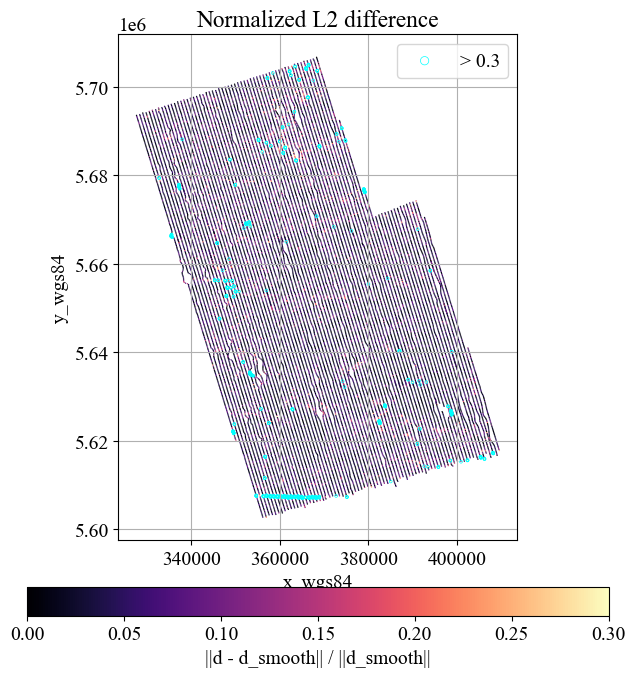

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
out = ax.scatter(
    xy_binned[plot_indices, 0],
    xy_binned[plot_indices, 1],
    c=normalized_l2_difference[plot_indices],
    s=1,
    cmap="magma",
    vmin=0,
    vmax=max(l2_threshold, np.nanpercentile(normalized_l2_difference, 98)),
    edgecolors="none",
)
ax.scatter(
    high_l2_locations["x_wgs84"],
    high_l2_locations["y_wgs84"],
    s=4,
    facecolors="none",
    edgecolors="cyan",
    linewidths=0.5,
    label=f"> {l2_threshold}",
)
cb = plt.colorbar(out, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08)
cb.set_label("||d - d_smooth|| / ||d_smooth||")
ax.set_xlabel("x_wgs84")
ax.set_ylabel("y_wgs84")
ax.set_aspect(1)
ax.set_title("Normalized L2 difference")
ax.legend(markerscale=3)
plt.tight_layout()
